<a href="https://colab.research.google.com/github/pydevcasts/MLHub/blob/master/detect_num_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

mnist = keras.datasets.mnist
(train_features, train_labels), (test_features, test_labels) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_features.shape

(60000, 28, 28)

In [ ]:
test_features.shape

(10000, 28, 28)

1


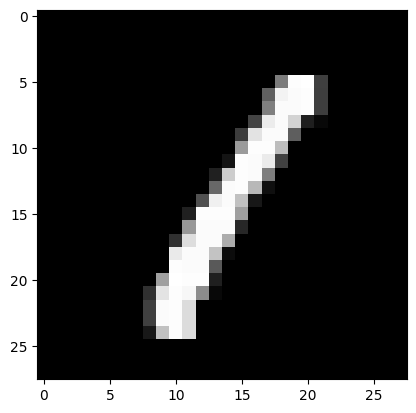

In [ ]:
count = 3
img = train_features[count]
print(train_labels[count])
plt.gray()
plt.imshow(img)

# **Preproccessing**


In [ ]:
np.min(img), np.max(img)

(0, 255)

In [ ]:
train_features = train_features / 255.0
test_features = test_features / 255.0

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(units=128, activation="relu"))
model.add(keras.layers.Dense(units=128, activation="relu"))
model.add(keras.layers.Dense(units=10, activation="softmax"))


In [ ]:
model.compile(optimizer=tf.optimizers.Adam(), loss=tf.losses.sparse_categorical_crossentropy,metrics=["accuracy"])
model.build(input_shape=(None, 28,28))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(train_features, train_labels, epochs=1000, batch_size=256, validation_data=(test_features, test_labels))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7835 - loss: 0.6848 - val_accuracy: 0.2608 - val_loss: 409.6481
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7844 - loss: 0.6950 - val_accuracy: 0.2630 - val_loss: 409.3077
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7875 - loss: 0.6899 - val_accuracy: 0.2656 - val_loss: 409.3334
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7872 - loss: 0.6853 - val_accuracy: 0.2675 - val_loss: 408.9953
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7821 - loss: 0.6936 - val_accuracy: 0.2707 - val_loss: 407.7839
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7855 - loss: 0.6791 - val_accuracy: 0.2722 - val_loss: 408.8059
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7897 - loss: 0.6724 - val_accuracy: 0.2737 - val_loss: 409.5750
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7960 - loss: 0.6625 - 

In [ ]:
model.evaluate(test_features, test_labels)

NameError: name 'model' is not defined

In [ ]:
ids=100
img = test_features[ids]
print(test_labels[ids])


6


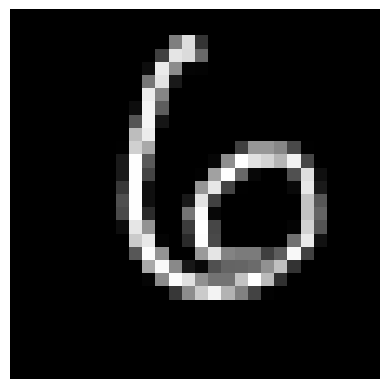

In [ ]:
plt.imshow(img, cmap='gray')  # Use 'gray' for grayscale images like MNIST

plt.axis('off')  # Turn off axis numbers and ticks
plt.show()


In [ ]:
test_data = np.reshape(img, (-1, 784))
test_data.shape

(1, 784)

In [ ]:
# Reshape test_data back to (1, 28, 28)
# test_data_reshaped = np.reshape(test_data, (1, 28, 28))

# Make predictions
predictions = model.predict(test_data)

# Display the predictions
print("Predictions:", predictions)

# Get the class with the highest probability
# predicted_class = np.argmax(predictions, axis=1)
# print("Predicted class:", predicted_class[0])


NameError: name 'model' is not defined

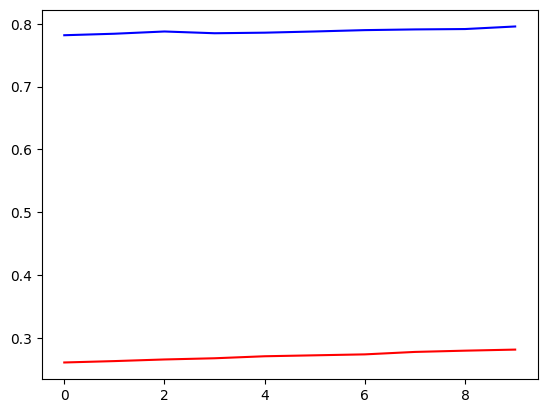

In [ ]:
acc = hist.history['accuracy']
val_acc=hist.history['val_accuracy']
plt.plot(acc, color="blue")
plt.plot(val_acc, color="red")
